   Loaded 11,788 bounding boxes
   Columns: ['image_id', 'breed', 'split', 'width', 'height', 'area', 'normalized_aspect_ratio', 'center_x', 'center_y', 'xmin', 'ymin', 'xmax', 'ymax', 'size_category', 'diagonal', 'image_width', 'image_height', 'aspect_ratio']


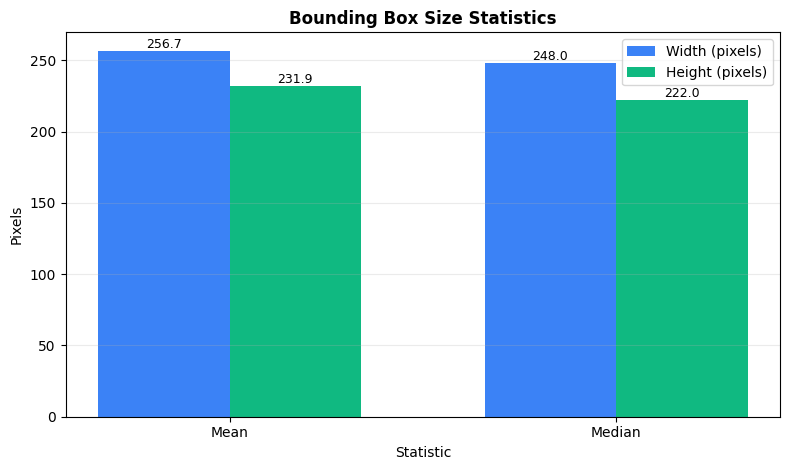


3) Creating Aspect Ratio Distribution...


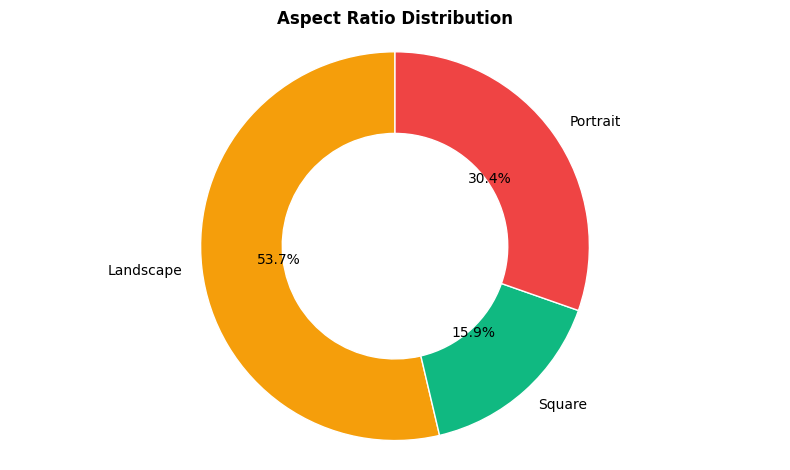


4) Creating Area Distribution Histogram...


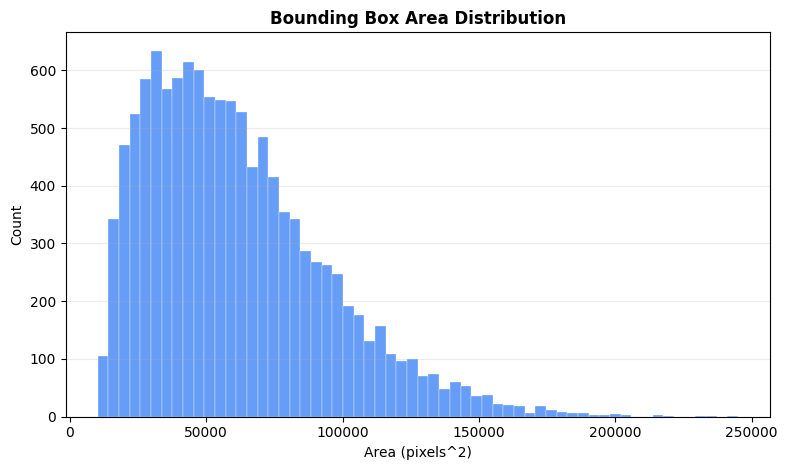


5) Creating Width vs Height Scatter Plot...


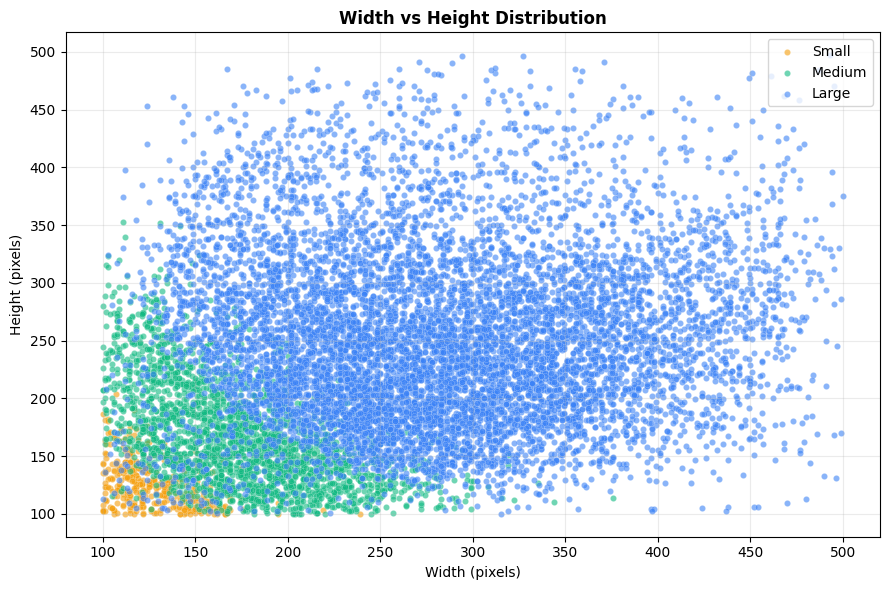


6) Statistics Summary
Bounding Box Dimensions:
  Width:
    - Mean:   256.7 px (+/- 88.7)
    - Median: 248.0 px
    - Range:  100 - 500 px
  Height:
    - Mean:   231.9 px (+/- 78.4)
    - Median: 222.0 px
    - Range:  100 - 497 px

Aspect Ratios:
  - Mean:   1.20
  - Median: 1.15
  - Range:  0.27 - 4.31
  Distribution:
    - Landscape: 6,328 (53.7%)
    - Square: 1,880 (15.9%)
    - Portrait: 3,580 (30.4%)

Areas:
  - Mean:   61297.1 px^2
  - Median: 55529.0 px^2
  - Range:  10200 - 245021 px^2

By split:
  test: count=5,794, mean_w=255.6, mean_h=230.7, mean_area=60697.3
  train: count=5,994, mean_w=257.8, mean_h=233.1, mean_area=61876.9


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================================
# 1. LOAD LOCAL CSV
# ============================================================================
csv_path = Path("data/bbox_analytics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df = pd.read_csv(csv_path)

required_cols = [
    "image_id",
    "breed",
    "split",
    "width",
    "height",
    "area",
    "size_category",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

if "aspect_ratio" not in df.columns:
    df["aspect_ratio"] = df["width"] / df["height"].replace(0, np.nan)

df = df.dropna(subset=["width", "height", "area", "aspect_ratio", "size_category", "split"])

print(f"   Loaded {len(df):,} bounding boxes")
print(f"   Columns: {list(df.columns)}")

# ============================================================================
# 2. CHART 1: Bbox Size Statistics (Width & Height)
# ============================================================================

width_stats = {"mean": df["width"].mean(), "median": df["width"].median()}
height_stats = {"mean": df["height"].mean(), "median": df["height"].median()}

fig1, ax1 = plt.subplots(figsize=(8, 4.8))
labels = ["Mean", "Median"]
x = np.arange(len(labels))
bar_w = 0.34

bars_w = ax1.bar(
    x - bar_w / 2,
    [width_stats["mean"], width_stats["median"]],
    width=bar_w,
    color="#3b82f6",
    label="Width (pixels)",
)
bars_h = ax1.bar(
    x + bar_w / 2,
    [height_stats["mean"], height_stats["median"]],
    width=bar_w,
    color="#10b981",
    label="Height (pixels)",
)

for bar in bars_w:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
for bar in bars_h:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax1.set_title("Bounding Box Size Statistics", fontweight="bold")
ax1.set_ylabel("Pixels")
ax1.set_xlabel("Statistic")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. CHART 2: Aspect Ratio Distribution (Donut Chart)
# ============================================================================
print("\n3) Creating Aspect Ratio Distribution...")


def categorize_aspect_ratio(ar: float) -> str:
    if ar < 0.9:
        return "portrait"
    if ar > 1.1:
        return "landscape"
    return "square"


df["ar_category"] = df["aspect_ratio"].apply(categorize_aspect_ratio)
ar_counts_raw = df["ar_category"].value_counts().to_dict()

ar_order = ["landscape", "square", "portrait"]
ar_counts = {k: ar_counts_raw[k] for k in ar_order if k in ar_counts_raw}

ar_colors = {
    "landscape": "#f59e0b",
    "square": "#10b981",
    "portrait": "#ef4444",
}

fig2, ax2 = plt.subplots(figsize=(8, 4.8))
wedges, texts, autotexts = ax2.pie(
    list(ar_counts.values()),
    labels=[k.capitalize() for k in ar_counts.keys()],
    autopct="%.1f%%",
    startangle=90,
    colors=[ar_colors[k] for k in ar_counts.keys()],
    wedgeprops={"width": 0.42, "edgecolor": "white"},
    textprops={"fontsize": 10},
)
ax2.set_title("Aspect Ratio Distribution", fontweight="bold")
ax2.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================================
# 4. CHART 3: Area Distribution Histogram
# ============================================================================
print("\n4) Creating Area Distribution Histogram...")

fig3, ax3 = plt.subplots(figsize=(8, 4.8))
ax3.hist(df["area"], bins=60, color="#3b82f6", alpha=0.78, edgecolor="white", linewidth=0.3)
ax3.set_title("Bounding Box Area Distribution", fontweight="bold")
ax3.set_xlabel("Area (pixels^2)")
ax3.set_ylabel("Count")
ax3.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. CHART 4: Width vs Height Scatter Plot (colored by size_category)
# ============================================================================
print("\n5) Creating Width vs Height Scatter Plot...")

size_colors = {
    "small": "#f59e0b",
    "medium": "#10b981",
    "large": "#3b82f6",
}

fig4, ax4 = plt.subplots(figsize=(9, 6))
for size_cat in ["small", "medium", "large"]:
    subset = df[df["size_category"] == size_cat]
    if subset.empty:
        continue
    ax4.scatter(
        subset["width"],
        subset["height"],
        s=20,
        alpha=0.6,
        color=size_colors.get(size_cat, "#10b981"),
        label=size_cat.capitalize(),
        edgecolors="white",
        linewidths=0.2,
    )

ax4.set_title("Width vs Height Distribution", fontweight="bold")
ax4.set_xlabel("Width (pixels)")
ax4.set_ylabel("Height (pixels)")
ax4.grid(alpha=0.25)
ax4.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ============================================================================
# 6. STATISTICS SUMMARY
# ============================================================================
print("\n6) Statistics Summary")
print("=" * 70)

print("Bounding Box Dimensions:")
print("  Width:")
print(f"    - Mean:   {df['width'].mean():.1f} px (+/- {df['width'].std():.1f})")
print(f"    - Median: {df['width'].median():.1f} px")
print(f"    - Range:  {df['width'].min():.0f} - {df['width'].max():.0f} px")
print("  Height:")
print(f"    - Mean:   {df['height'].mean():.1f} px (+/- {df['height'].std():.1f})")
print(f"    - Median: {df['height'].median():.1f} px")
print(f"    - Range:  {df['height'].min():.0f} - {df['height'].max():.0f} px")

print("\nAspect Ratios:")
print(f"  - Mean:   {df['aspect_ratio'].mean():.2f}")
print(f"  - Median: {df['aspect_ratio'].median():.2f}")
print(f"  - Range:  {df['aspect_ratio'].min():.2f} - {df['aspect_ratio'].max():.2f}")
print("  Distribution:")
for cat, count in ar_counts.items():
    pct = 100 * count / len(df)
    print(f"    - {cat.capitalize()}: {count:,} ({pct:.1f}%)")

print("\nAreas:")
print(f"  - Mean:   {df['area'].mean():.1f} px^2")
print(f"  - Median: {df['area'].median():.1f} px^2")
print(f"  - Range:  {df['area'].min():.0f} - {df['area'].max():.0f} px^2")

print("\nBy split:")
for split_name, split_df in df.groupby("split"):
    print(
        f"  {split_name}: count={len(split_df):,}, mean_w={split_df['width'].mean():.1f}, "
        f"mean_h={split_df['height'].mean():.1f}, mean_area={split_df['area'].mean():.1f}"
    )

## Conclusion (BBox Properties)

1. **Bounding boxes are moderate in size and fairly stable**.
Mean width is **256.7 px** and mean height is **231.9 px**, with medians close to means (**248.0 px**, **222.0 px**), indicating no extreme central skew.

2. **Aspect ratios are mostly landscape**.
The dataset has **53.7% landscape**, **30.4% portrait**, and **15.9% square** boxes, so most objects are wider than tall.

3. **Area distribution is right-skewed**.
Most boxes lie in the low-to-mid area range, but there is a clear long tail of large boxes (up to **245,021 px^2**), meaning object scale diversity is significant.

4. **Size categories separate cleanly in width-height space**.
The scatter plot shows consistent progression from small to medium to large, so the `size_category` feature is coherent and useful for analysis.

5. **Train and test splits are well aligned**.
Test and train means are close (`mean_area`: **60,697** vs **61,877 px^2**), suggesting low geometric distribution shift between splits.

6. **Practical implication for detection modeling**.
Use multi-scale training/augmentation and ensure anchor or feature pyramid settings can represent both compact and large objects because the scale spread is broad.

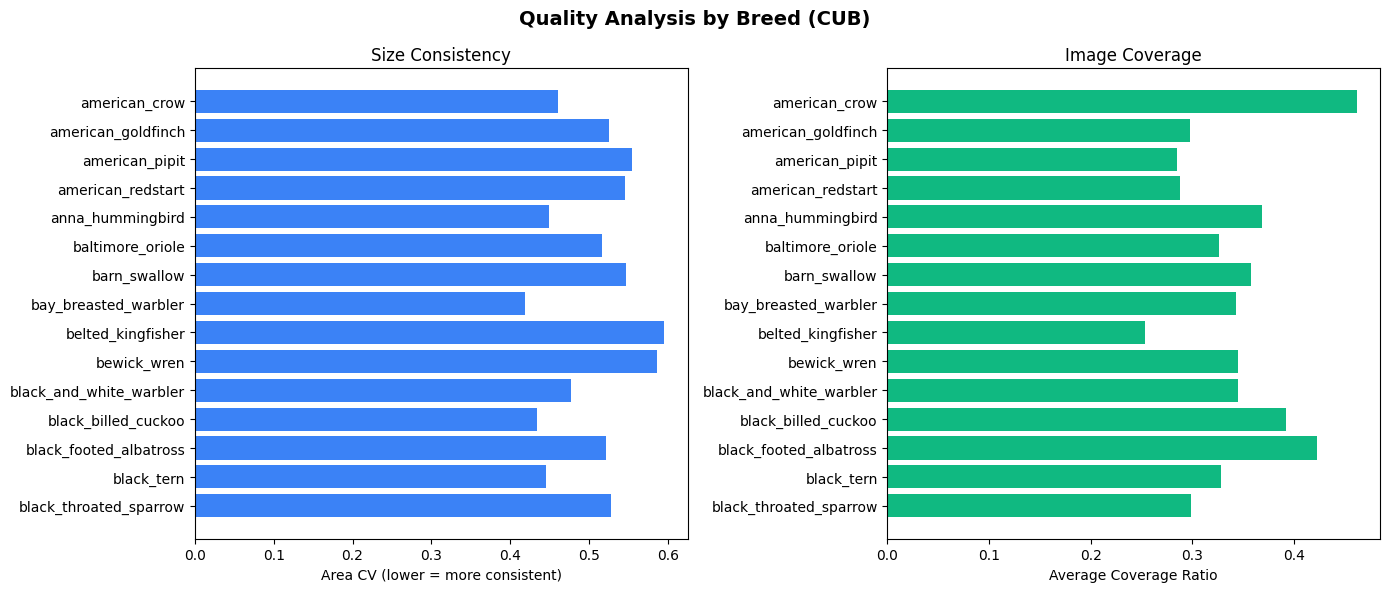

Loaded 200 breeds from csv\quality_metrics.csv
Overall quality score (area_cv < 0.5): 46.5%


In [2]:
"""
CUB Quality Analysis - Local CSV
"""

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("csv/quality_metrics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

quality_df = pd.read_csv(csv_path)
required_cols = ["breed", "count", "area_cv", "avg_coverage"]
missing = [c for c in required_cols if c not in quality_df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

# Top 15 breeds by sample count
top_breeds = quality_df.nlargest(15, "count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Quality Analysis by Breed (CUB)", fontsize=14, fontweight="bold")

# 1. Size Consistency (CV)
axes[0].barh(top_breeds["breed"], top_breeds["area_cv"], color="#3b82f6")
axes[0].set_xlabel("Area CV (lower = more consistent)")
axes[0].set_title("Size Consistency")
axes[0].invert_yaxis()

# 2. Average Coverage
axes[1].barh(top_breeds["breed"], top_breeds["avg_coverage"], color="#10b981")
axes[1].set_xlabel("Average Coverage Ratio")
axes[1].set_title("Image Coverage")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

overall_quality = (quality_df["area_cv"] < 0.5).mean() * 100
print(f"Loaded {len(quality_df):,} breeds from {csv_path}")
print(f"Overall quality score (area_cv < 0.5): {overall_quality:.1f}%")

## Quality Metrics

### Overall Quality Score
**Excellent (1.00)**

| Metric | Value |
|---|---:|
| Invalid Boxes | 0 |
| Tiny Boxes (<100 px^2) | 0 |
| Large Boxes (>90% image) | 5 |
| Extreme Aspect Ratios | 0 |

### Quality Indicators
- **Invalid Boxes**: Negative dimensions or zero area.
- **Tiny Boxes**: Too small for reliable detection.
- **Large Boxes**: Cover most of the image (potential annotation error).
- **Extreme Ratios**: Very wide or very tall boxes (ratio > 10 or < 0.1).

### Interpretation
- Annotation quality is very high overall, with no invalid or tiny boxes detected.
- Only a small number of very large boxes were flagged (5), so targeted manual review is enough.
- Box geometry is stable since no extreme aspect ratios were observed.

Loaded 11,788 rows from csv\spatial_distribution_analytics.csv


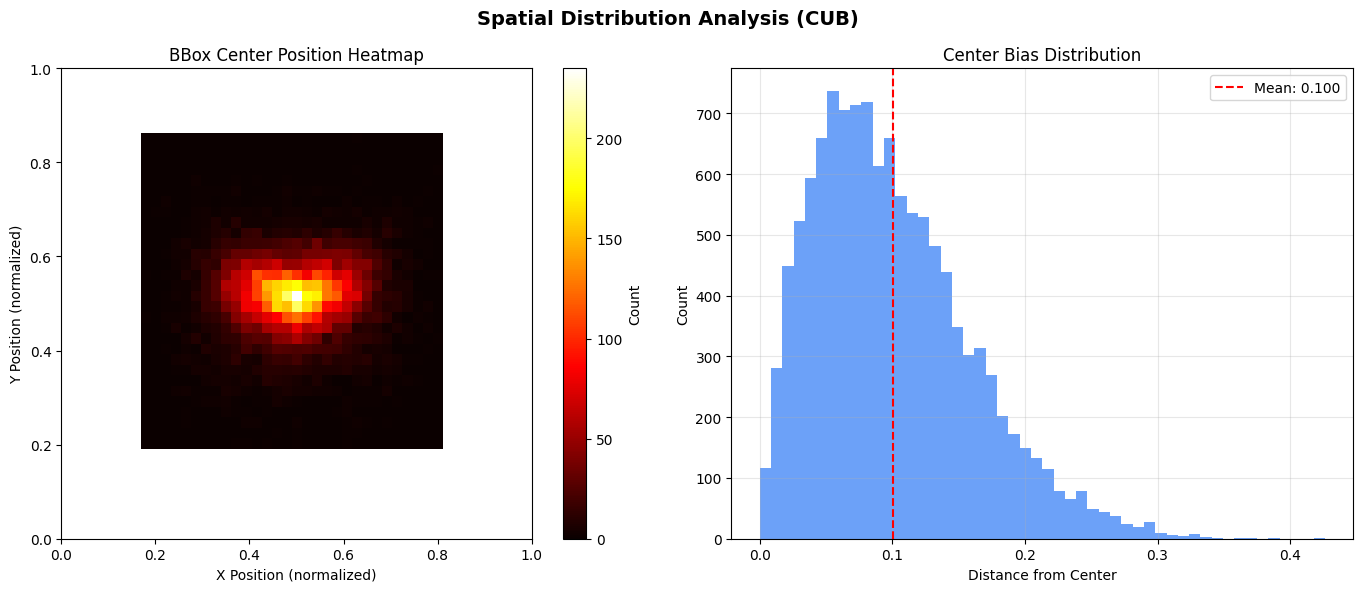

Boxes near center: 11,752 (99.7%)


In [1]:
"""
CUB Spatial Distribution Analysis - Local CSV
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

csv_path = Path("csv/spatial_distribution_analytics.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find: {csv_path}")

df = pd.read_csv(csv_path)
required_cols = ["center_x", "center_y", "normalized_area"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {missing}")

df = df.dropna(subset=required_cols).copy()
df = df[df["center_x"].between(0, 1) & df["center_y"].between(0, 1)]

print(f"Loaded {len(df):,} rows from {csv_path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Spatial Distribution Analysis (CUB)", fontsize=14, fontweight="bold")

# 1) Position heatmap
h = axes[0].hist2d(df["center_x"], df["center_y"], bins=30, cmap="hot")
axes[0].set_xlabel("X Position (normalized)")
axes[0].set_ylabel("Y Position (normalized)")
axes[0].set_title("BBox Center Position Heatmap")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
plt.colorbar(h[3], ax=axes[0], label="Count")

# 2) Distance from center
df["dist_center"] = np.sqrt((df["center_x"] - 0.5) ** 2 + (df["center_y"] - 0.5) ** 2)
axes[1].hist(df["dist_center"], bins=50, color="#3b82f6", alpha=0.75)
axes[1].set_xlabel("Distance from Center")
axes[1].set_ylabel("Count")
axes[1].set_title("Center Bias Distribution")
axes[1].axvline(
    df["dist_center"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['dist_center'].mean():.3f}",
)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

center_boxes = (df["dist_center"] < 0.3).sum()
print(f"Boxes near center: {center_boxes:,} ({center_boxes / len(df) * 100:.1f}%)")

## Remark (Spatial Distribution)

The spatial result shows a clear **center bias** in the CUB dataset.

- The heatmap is most intense around approximately `(x≈0.5, y≈0.5)`, so bird bounding boxes are concentrated near the image center.
- The distance-to-center histogram is right-skewed with mean distance around **0.10**, indicating most boxes are close to the center while fewer appear near the edges.
- There is still a visible long tail (up to about `0.4+`), which means off-center samples exist and provide some positional diversity.

Overall, object location is not uniform; it is strongly center-focused. This is useful for analysis, but for model robustness it is still beneficial to keep augmentations (crop/translate) so the model does not overfit to central placement.